In [1]:
import random
import networkx as nx
import torch
import torch.nn as nn

from deep_ebm.utils_ebm import show_graph, evaluate_model
from deep_ebm.utils_ebm import save_graph, compare_graphs, show_graph_grid, compare_statistics
from deep_ebm.gnn_ebm import GraphDataset, GNN_EBM, train_one_epoch_pcd, gibbs_ministeps

from src.torch_erg import load_pglib_opf as lp
from src.torch_erg.samplers import GWGSampler, MHSampler, GWG_Hybrid_Sampler
from src.torch_erg.utils import laplacian_matrix
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

from Plots_and_utils.plots import *
from Plots_and_utils.other_g_stats import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
with open("Saved_models/30IEEE_GNN_EBM_20epochs_2500GS.pkl", "rb") as f:
    model_30IEEE= pkl.load(f)

In [3]:
with open("data/30IEEE_synth_dataset/reduced_30IEEE_synth_list_GraphDataset.pkl", "rb") as f:
    dataset_30IEEE = pkl.load(f)

In [19]:
name = '30_ieee'

# soft connectivity constraint flag, if false then hard constraint is used
SOFT_CONN = True

ordmat, ordlist, buslist, countlist = lp.pow_parser(name)

ordmat = torch.tensor(ordmat)
ordlist = torch.tensor(ordlist)
buslist = torch.tensor(buslist)
countlist = torch.tensor(countlist)

G_sparse = ordmat.cpu().numpy()  # Create sparse matrix
n_components = connected_components(csr_matrix(G_sparse))
print("Number of connected components in the graph:", n_components[0])

class MySampler(GWG_Hybrid_Sampler):
    def __init__(self, backend: str, model: nn.Module):
        super().__init__(backend, model)
        self.model = model
    def observables(self, mtx):
        edges = torch.sum(mtx)/2
        triangles = torch.trace(torch.matmul(torch.matmul(mtx,mtx),mtx))/6
        #ac = torch.linalg.eigvalsh(laplacian_matrix(mtx))[1]
        return(torch.stack([edges, triangles]))
        
betas = torch.tensor([-1., -1.], dtype=float)


Number of connected components in the graph: 1


In [20]:
#we freeze the node features as we do not need them, so that we can evaluate the model only on the adj matrix
class feat_encoded_model(nn.Module):
    def __init__(self, model, feats):
        super().__init__()
        self.model = model
        self.feats = feats.to(device)

    def forward(self,adj):
        return(self.model(self.feats, adj))

In [13]:
A, feats = dataset_30IEEE[0]

In [21]:
model_30IEEE.eval()
adj_model = feat_encoded_model(model_30IEEE, feats)

sampler = MySampler(backend="cuda",model = adj_model)
obs = sampler.observables(ordmat)
print("observed observables: ", obs)
ordmat = ordmat.to(device)
params, _ = sampler.param_run(graph=ordmat,
                      observables=obs,
                      params=betas,
                      niter=10000,
                      params_update_every=3,
                      save_every=50,
                      save_params=True,
                      alpha=0.005,                      
                      min_change = 0.001)

CUDA backend not available falling back to cpu
observed observables:  tensor([41.,  6.], dtype=torch.float64)


  0%|          | 7/10000 [00:00<02:29, 67.04it/s]

comp ham is:  tensor(28.9137, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-47., dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(25.8768, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-47., dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(25.8768, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-49., dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(23.0459, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-49., dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(25.8768, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-49., dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(20.7243, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-49., dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(25.8768, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-49., dtype=torch.float64, grad_fn=<DotBackward0

  0%|          | 15/10000 [00:00<02:23, 69.46it/s]

new ham is:  tensor(40.2164, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-45.1999, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(40.2164, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-43.1949, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(35.8358, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-43.1949, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(40.2164, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-43.1949, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(37.4142, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-43.1949, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(40.2164, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-43.1949, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(36.9224, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-43.1949, dtype=torch

...

new ham is:  tensor(87.9943, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-7.0391, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(92.9639, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-7.0391, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(93.0744, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-7.0391, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(93.0744, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.8092, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(87.5306, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-6.8092, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(93.0744, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.8092, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(89.8027, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-6.8092, dtype=torch.float6

100%|█████████▉| 9985/10000 [02:05<00:00, 69.54it/s]

comp ham is:  tensor(93.1085, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.7752, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(90.6404, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-6.7752, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(93.1085, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.7752, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(87.2751, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-6.7752, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(93.1085, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.7752, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(89.8135, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-6.7752, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(93.1085, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.7752, dtype=torch.float64, 

100%|██████████| 10000/10000 [02:05<00:00, 79.70it/s]

comp ham is:  tensor(98.4877, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.3471, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(95.3288, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-6.3471, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(98.4877, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.3471, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(97.3422, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-6.3471, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(97.3422, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.5747, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(92.5100, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-6.5747, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(97.3422, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-6.5747, dtype=torch.float64, 

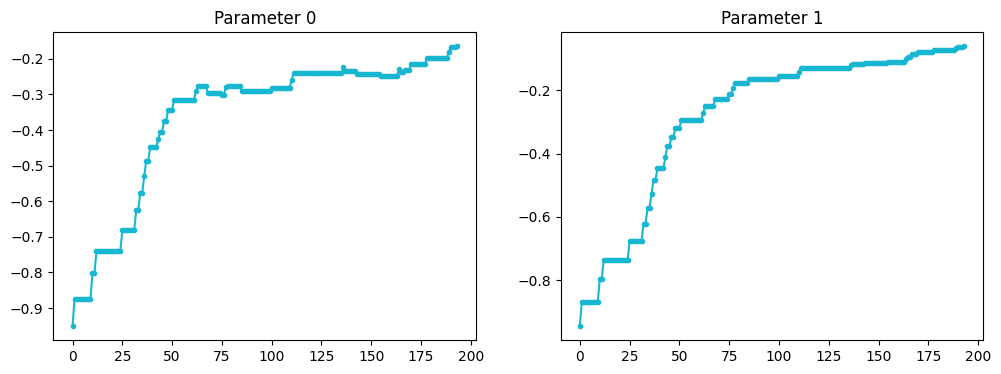

In [22]:
plot_params_iterations(params)

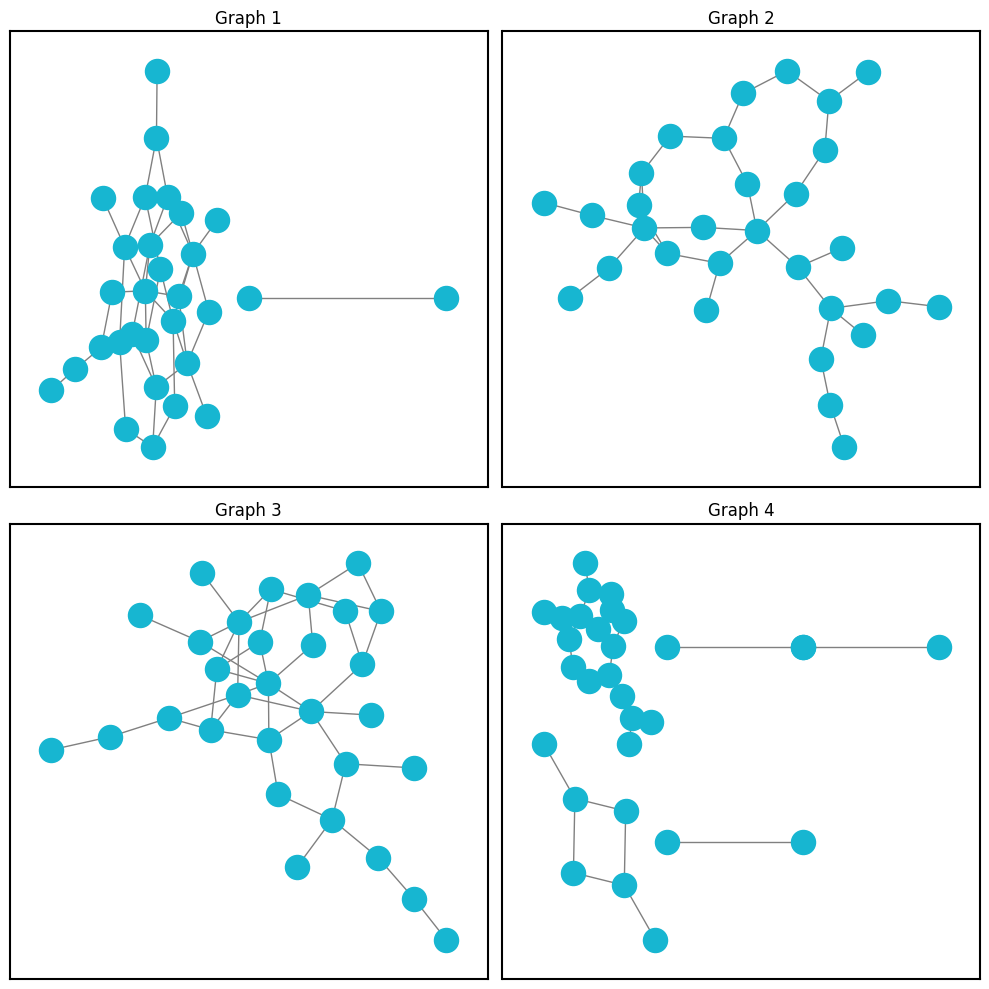

In [24]:
plot_random_graphs(_, 4)

In [25]:
params_for_estimates = torch.stack(params[-50:]).mean(axis = 0)
params_for_estimates

tensor([-0.2204, -0.0905], dtype=torch.float64)

In [26]:
observables, graphs = sampler.sample_run(graph=ordmat,
                      observables=obs,
                      params=params_for_estimates,
                      niter=10000,
                      save_every=50,
                      burn_in=0.2)

  0%|          | 8/10000 [00:00<02:19, 71.78it/s]

comp ham is:  tensor(66.3329, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-9.5808, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(61.5189, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-9.5808, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(66.3329, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-9.5808, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(63.2356, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-9.5808, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(66.3329, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-9.5808, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(71.1924, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-9.5808, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(71.1924, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-9.2699, dtype=torch.float64, 

  0%|          | 23/10000 [00:00<03:07, 53.24it/s]

comp ham is:  tensor(70.7071, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-9.4904, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(69.2431, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-9.4904, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(70.7071, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-9.4904, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(68.8865, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-9.4904, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(70.7071, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-9.4904, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(66.9779, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-9.4904, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(70.7071, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-9.4904, dtype=torch.float64, 

  0%|          | 29/10000 [00:00<03:04, 53.99it/s]

...

tensor(-8.3372, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(101.1047, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.3372, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(96.1884, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.3372, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(101.1047, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.3372, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(94.6738, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.3372, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(101.1047, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.3372, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(98.8559, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.3372, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(98.8559, dtype=torch.float64, grad_f

100%|█████████▉| 9983/10000 [02:10<00:00, 99.75it/s]

tensor(98.2175, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.5577, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(95.2042, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.5577, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(98.2175, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.5577, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(94.0221, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.5577, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(98.2175, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.5577, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(94.9580, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.5577, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(98.2175, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.5577, dtype=torch.float64, grad_fn=<DotBa

100%|██████████| 10000/10000 [02:11<00:00, 76.29it/s]

comp ham is:  tensor(95.6512, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.7781, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(93.5114, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.7781, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(95.6512, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.7781, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(94.1867, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.7781, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(94.1867, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.9986, dtype=torch.float64, grad_fn=<DotBackward0>)
new ham is:  tensor(93.2169, dtype=torch.float64, grad_fn=<AddBackward0>)
old ham is:  tensor(-8.9986, dtype=torch.float64, grad_fn=<DotBackward0>)
comp ham is:  tensor(94.1867, dtype=torch.float64, grad_fn=<AddBackward0>)
ham is:  tensor(-8.9986, dtype=torch.float64, 

In [27]:
len(graphs)

164

In [31]:
len(connected_graphs(sampler, graphs, 1)), len(graphs)

(2, 164)

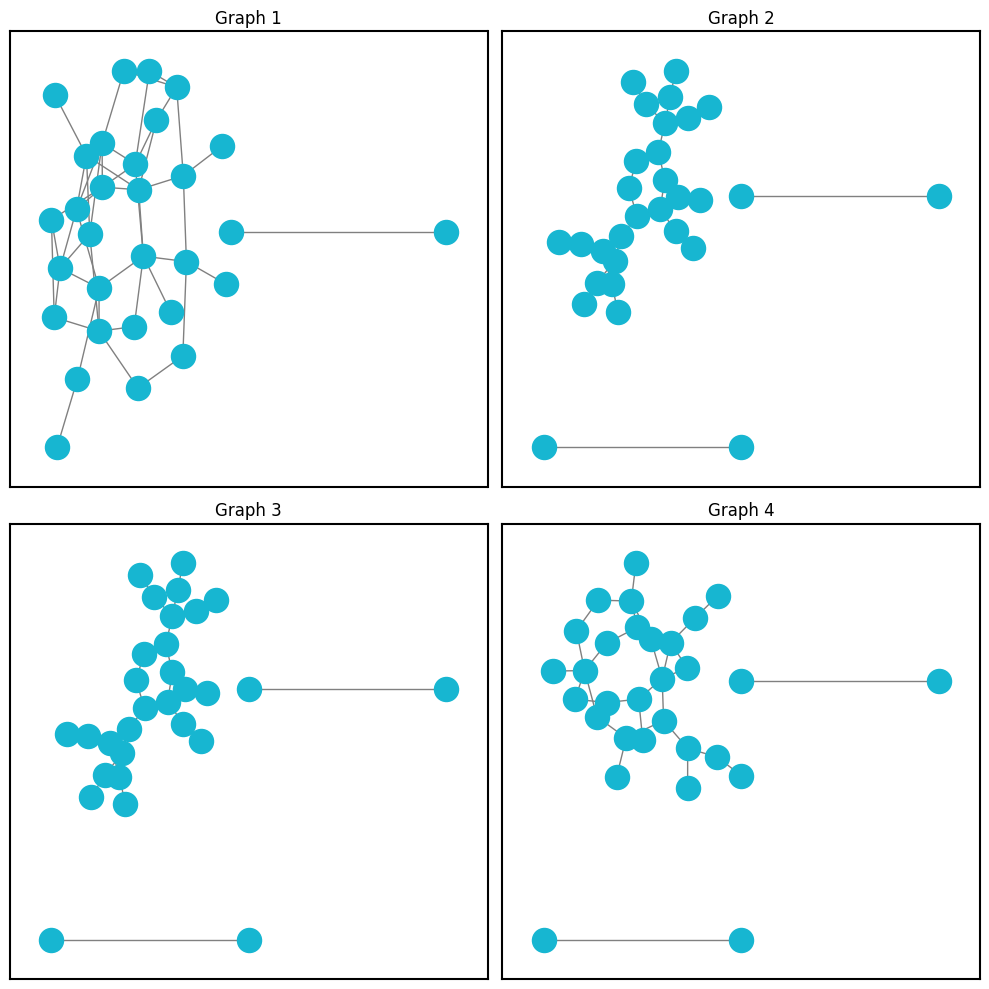

In [36]:
plot_random_graphs(graphs, 4)